# Single Band Photometry and Matching

## 1. Initial Setting

In [56]:
from astropy.table import Table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import (
    ImageNormalize,
    ZScaleInterval,
    PercentileInterval,
    AsinhStretch,
    LogStretch,
    SqrtStretch
)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import glob
from pathlib import Path
import subprocess
from tqdm.auto import tqdm

def get_image_path(cosmos, band, weight=False):
    image_folder = DATA_ROOT / f"COSMOS{cosmos}"

    suffix = "weight.fits" if weight else "com.fits"
    paths = list(image_folder.glob(f"*{band}*.{suffix}"))

    if len(paths) == 0:
        print(
            f"COSMOS {cosmos} - {band}: no matching {suffix} file."
        )
        return None

    if len(paths) > 1:
        raise RuntimeError(
            f"COSMOS {cosmos} - {band}: multiple matching {suffix} files."
        )

    return paths[0]

def get_catalog_path(cosmos, band):
    return PROJECT_ROOT / f'output/COSMOS{cosmos}/COSMOS_{cosmos}_cat_{band}.fits'

def plot_ImageAndDetectedSources(image, cat, pixel_range=None):
    # pixel_range = np.array([[xmin, xmax], [ymin, ymax]])

    if pixel_range is not None:
        xmin = pixel_range[0][0]
        xmax = pixel_range[0][1]
        ymin = pixel_range[1][0]
        ymax = pixel_range[1][1]

        cat_plot = cat[
            (xmin <= cat['pixel_centroid_x'])
            & (cat['pixel_centroid_x'] < xmax)
            & (ymin <= cat['pixel_centroid_y'])
            & (cat['pixel_centroid_y'] < ymax)
        ]

        image_plot = image[ymin:ymax, xmin:xmax]

    else:
        ymin, xmin = 0, 0
        ymax, xmax = image.shape

        cat_plot = cat
        image_plot = image

    norm = ImageNormalize(
        image_plot,
        interval=ZScaleInterval()
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(
        image_plot,
        cmap='gray',
        norm=norm,
        origin='lower',
        extent=[xmin, xmax, ymin, ymax]
    )

    radius_pix = 5.94

    for x, y in zip(
        cat_plot['pixel_centroid_x'],
        cat_plot['pixel_centroid_y']
    ):
        ax.add_patch(
            Circle(
                (x, y),
                radius=radius_pix,
                fill=False,
                edgecolor='red',
                linewidth=1
            )
        )

    ax.set_xlabel('X pixel')
    ax.set_ylabel('Y pixel')

    plt.show()

# Image preparation
COSMOS = 1
PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT/'COSMOS_data'
BANDS_7DT = [f"m{i}" for i in range(400, 900, 25)]
MASK_ROOT = DATA_ROOT / f"COSMOS{COSMOS}/COSMOS{COSMOS}_validmask.fits"

valid_mask = fits.open(MASK_ROOT)[0].data
valid_mask = valid_mask.astype(bool)

# Make available bands
available_band = []
image_paths = {}
weight_paths = {}
zero_points = {}

for band in BANDS_7DT : 
    band_path = get_image_path(COSMOS, band)
    weight_path = get_image_path(COSMOS, band, weight=True)
    if band_path is None : continue
    available_band.append(band)
    image_paths[band] = band_path
    weight_paths[band] = weight_path
    with fits.open(band_path) as hdul : 
        header = hdul[0].header
    zero_points[band] = float(header['ZP_3'])

print(f'{len(available_band)} bands are available.')

first_band = available_band[0]
with fits.open(image_paths[first_band]) as hdul : 
    data = hdul[0].data
    wcs = WCS(hdul[0].header)

PIXEL_SCALE = (proj_plane_pixel_scales(wcs)[0] * u.deg).to(u.arcsec)
APER_3ARCSEC_PIXEL = 3 * u.arcsec / PIXEL_SCALE
DETECTION_THRESHOLD = 3
DETECTION_MINIMUM_AREA = 1
THREAD_COUNT = 1


20 bands are available.


## 2. Single Band Photometry

In [ ]:
for band in tqdm(available_band):
    image_path = image_paths[band]
    weight_path = weight_paths[band]

    pyconfig_path = PROJECT_ROOT / f"seppconfig/singlephot_cosmos{COSMOS}_{band}.py"
    config_path = PROJECT_ROOT / f"seppconfig/singlephot_cosmos{COSMOS}_{band}.config"
    pyconfig_path.parent.mkdir(parents=True, exist_ok=True)
    zero_point = zero_points[band]
    
    catalog_path = (
        PROJECT_ROOT
        / f"output/COSMOS{COSMOS}/singbandphot"
        / f"cat_cosmos{COSMOS}_{band}.fits"
    )
    catalog_path.parent.mkdir(parents=True, exist_ok=True)

    pyconfig_code = f"""
from sourcextractor.config import *

image_group = load_fits_image(
    {str(image_path)!r},
    # weight={str(weight_path)!r},
    # weight_type='weight'
)

meas_group = MeasurementGroup(image_group)

aper = []

for img in meas_group:
    aper.extend(
        add_aperture_photometry(
            img,
            {APER_3ARCSEC_PIXEL}
        )
    )

add_output_column("aper3", aper)
"""


    config_code = f"""
detection-image={image_path}

detection-threshold={DETECTION_THRESHOLD}
detection-minimum-area={DETECTION_MINIMUM_AREA}
magnitude-zero-point={zero_point}

python-config-file={pyconfig_path}

output-properties=SourceIDs,PixelCentroid,WorldCentroid,AperturePhotometry,SNRRatio,ShapeParameters,FluxRadius
output-catalog-filename={catalog_path}

segmentation-use-filtering=false
thread-count={THREAD_COUNT}
"""
    pyconfig_path.write_text(pyconfig_code)
    config_path.write_text(config_code) 
    
    command = [
        'sourcextractor++', 
        '--config-file', 
        str(config_path)
    ]
    
    subprocess.run(command, check=True)
    break

print('Single Band Catalog Process finished')

  0%|          | 0/20 [00:00<?, ?it/s]

2026-08-30T23:54:34KST FitsFile  INFO : Creating shared LRUFileManager with limit of 500 open files.
2026-08-30T23:54:35KST BackgroundModel  INFO : Background for image: Masked(BufferedImage(/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240528_234348_m400_4320.com.fits)) with 0.0 weight image masked pixels; median: 1.11128 rms: 1.97927!
2026-08-30T23:54:36KST BackgroundModel  INFO : Background for image: Masked(BufferedImage(/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240528_234348_m400_4320.com.fits)) with 0.0 weight image masked pixels; median: 1.11128 rms: 1.97927!
2026-08-30T23:54:36KST FlexibleModelFitting  INFO : Using engine levmar with the iterative implementation and 200 maximum number of iterations, window type: 1
2026-08-30T23:54:36KST SourceXtractor  INFO : Writing output following segmentation order
2026-08-30T23:54:36KST SourceXtractor  INFO : Processing frame 1 / 1 : calib_7DT_COSMOS_1_20240528_2

Single Band Catalog Process finished


2026-08-30T23:55:57KST SourceXtractor  INFO : 206036 sources detected in frame, 206036 total
2026-08-30T23:55:57KST Progress  INFO : Segmentation: 6800 / 6800 (100.00%)
2026-08-30T23:55:57KST Progress  INFO : Detected: 205527
2026-08-30T23:55:57KST Progress  INFO : Deblended: 206036
2026-08-30T23:55:57KST Progress  INFO : Measured: 206036 / 206036 (100.00%)
2026-08-30T23:55:57KST Progress  INFO : Elapsed: 00:01:23
2026-08-30T23:55:57KST SourceXtractor  INFO : total 206036 sources detected
2026-08-30T23:55:57KST Python::Interpreter  INFO : Python GIL acquired 19 times


Check the result

Detected Sources(good) : 133557
source_id detection_id pixel_centroid_x  pixel_centroid_y world_centroid_alpha world_centroid_delta aper3_flux aper3_flux_err aper3_mag aper3_mag_err aper3_flags  snrratio     ellipse_a         ellipse_b        ellipse_theta       ellipse_cxx         ellipse_cyy          ellipse_cxy       area     elongation         ellipticity      flux_radius 
                             pix               pix                deg                  deg              ct           ct          mag         mag                                   pix               pix                deg             pixel^{-2}          pixel^{-2}           pixel^{-2}       pix                                              pix     
--------- ------------ ---------------- ----------------- -------------------- -------------------- ---------- -------------- --------- ------------- ----------- --------- ----------------- ------------------ ----------------- ------------------- ------------------- -----

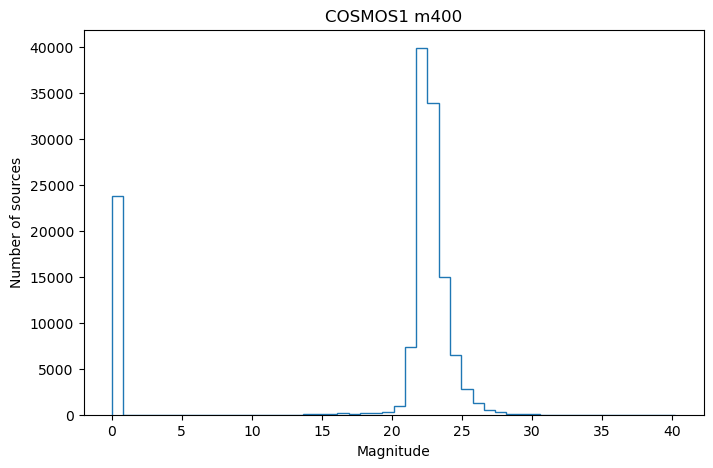

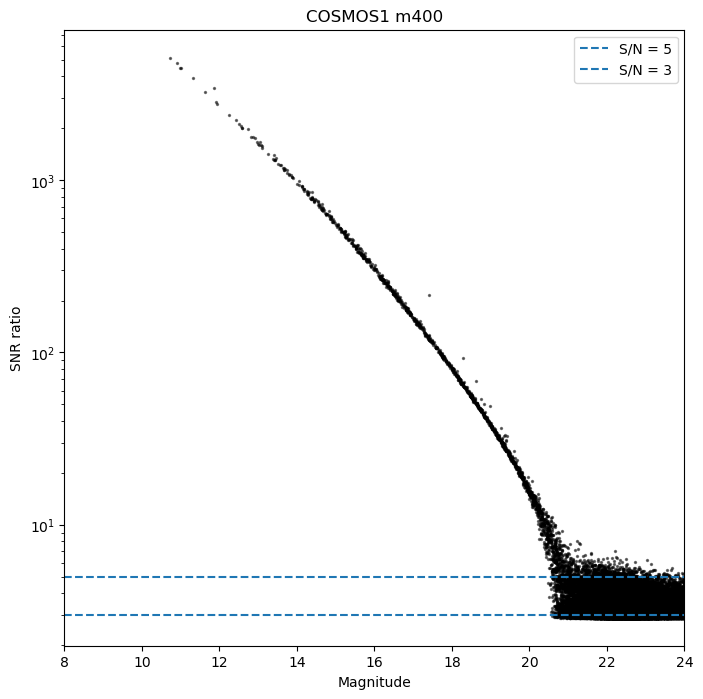

In [59]:
test_band = 'm400'
image_path = image_paths['m400']
catalog_path = (
        PROJECT_ROOT
        / f"output/COSMOS{COSMOS}/singbandphot"
        / f"cat_cosmos{COSMOS}_{test_band}.fits"
)

det = fits.getdata(image_path)
cat = Table.read(catalog_path)
cat = cat[cat['aper3_flags']==0]

# catalog masking
cat_x_array = np.rint(cat['pixel_centroid_x']).astype(int)
cat_y_array = np.rint(cat['pixel_centroid_y']).astype(int)
valid_source = valid_mask[cat_y_array, cat_x_array]
cat = cat[valid_source]

print(f'Detected Sources(good) : {len(cat)}')
cat[:20].pprint(max_width=-1)

# plot_ImageAndDetectedSources(
#         det, cat, 
#         #pixel_range=[[3000, 4000], [3000, 4000]]
# )

# Statistical Plots
# 1. Histogram
mag = np.asarray(cat['aper3_mag'])
plt.figure(figsize=(8, 5))
plt.hist(mag, bins=50, histtype='step')
plt.xlabel("Magnitude")
plt.ylabel("Number of sources")
plt.title(f"COSMOS{COSMOS} {test_band}")
plt.show()
plt.close()

# 2. SNR - Mag Plot
snr = np.asarray(cat['snrratio'])

plt.figure(figsize=(8, 8))
plt.scatter(
        mag, 
        snr, 
        s=2,
        marker='o',
        alpha=0.5,
        color='black'
)
plt.xlabel("Magnitude")
plt.ylabel("SNR ratio")
plt.yscale('log')
plt.xlim(8, 24)
#plt.ylim(3, 30)
plt.axhline(5, linestyle="--", label="S/N = 5")
plt.axhline(3, linestyle="--", label="S/N = 3")
plt.legend()
plt.title(f"COSMOS{COSMOS} {test_band}")
plt.show()
plt.close()
